# Project: Advanced Credit Risk Prediction
## Notebook 04: Individual Risk Modeling (Retail Track)

[![Author](https://img.shields.io/badge/Author-Prakash%20Ukhalkar-blue.svg)](https://github.com/prakash-ukhalkar) [![GitHub Repository](https://img.shields.io/badge/GitHub-Repo-lightgrey)](https://github.com/prakash-ukhalkar/Advanced-Credit-Risk-Prediction) [![Scikit-Learn](https://img.shields.io/badge/Scikit--Learn-Latest-orange)](https://scikit-learn.org/) [![XGBoost](https://img.shields.io/badge/XGBoost-Latest-green)](https://xgboost.readthedocs.io/) [![LightGBM](https://img.shields.io/badge/LightGBM-Latest-blue)](https://lightgbm.readthedocs.io/)

---

**Objective:** Train, evaluate, and compare multiple machine learning algorithms on the preprocessed Individual/Retail dataset.

**Introduction:** This notebook focuses on the modeling phase for individual credit risk. We establish an academic baseline using Logistic Regression and contrast its performance against modern ensemble learners: Random Forest, XGBoost, and LightGBM. Highlighting the high financial cost of False Negatives (type II errors) in credit lending, we prioritize Recall and ROC-AUC as our primary success metrics.

## Step 1: Library Imports
We utilize a comprehensive suite of libraries for modeling. This includes `scikit-learn` for traditional algorithms and metrics, and specialized gradient boosting frameworks (`xgboost`, `lightgbm`) known for state-of-the-art performance on tabular financial data.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Metrics
from sklearn.metrics import (
    classification_report, 
    roc_auc_score, 
    roc_curve, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## Step 2: Data Loading (Modular Hand-off)
We load the preprocessed datasets generated and serialized in **Notebook 03**. Using the `joblib` format ensures that the structure and types of the feature matrices mapped during engineering (Scaling, One-Hot Encoding) are perfectly preserved.

In [6]:
PROCESSED_DATA_DIR = os.path.join('..', 'data', 'processed')

X_train = joblib.load(os.path.join(PROCESSED_DATA_DIR, 'X_ret_train_final.joblib'))
y_train = joblib.load(os.path.join(PROCESSED_DATA_DIR, 'y_ret_train.joblib'))
X_test = joblib.load(os.path.join(PROCESSED_DATA_DIR, 'X_ret_test_final.joblib'))
y_test = joblib.load(os.path.join(PROCESSED_DATA_DIR, 'y_ret_test.joblib'))

print(f"Retail Training Set: {X_train.shape}")
print(f"Retail Testing Set: {X_test.shape}")

Retail Training Set: (800, 58)
Retail Testing Set: (200, 58)


## Step 3: Baseline Modeling (Logistic Regression)
Logistic Regression serves as our academic baseline. It is highly interpretable and provides a linear decision boundary benchmark. In credit risk research, a complex model must significantly outperform this baseline to justify its implementation complexity and reduced transparency.

In [7]:
# Initialize Baseline
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_score_lr = lr_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_score_lr):.4f}")

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       141
           1       0.67      0.44      0.53        59

    accuracy                           0.77       200
   macro avg       0.73      0.67      0.69       200
weighted avg       0.76      0.77      0.75       200

ROC-AUC Score: 0.7607


## Step 4: Ensemble & Gradient Boosting Models
We now transition to ensemble learning. **Random Forest** provides robustness against overfitting through bagging. **XGBoost** and **LightGBM** utilize gradient boosting, which iteratively corrects errors of previous trees, making them exceptionally powerful for capturing non-linear relationships in behavioral credit data.

In [8]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(random_state=42, verbosity=-1)
}

results = {"Logistic Regression": y_score_lr}
reports = {"Logistic Regression": classification_report(y_test, y_pred_lr, output_dict=True)}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]
    
    results[name] = y_score
    reports[name] = classification_report(y_test, y_pred, output_dict=True)
    
    print(f"{name} ROC-AUC: {roc_auc_score(y_test, y_score):.4f}")


Training Random Forest...
Random Forest ROC-AUC: 0.7119

Training XGBoost...
XGBoost ROC-AUC: 0.7644

Training LightGBM...
LightGBM ROC-AUC: 0.7722


## Step 5: Metric Evaluation & Risk Context
In Credit Risk, **Recall** is frequently more critical than Precision. A 'False Positive' (rejecting a good borrower) results in lost interest revenue, but a 'False Negative' (accepting a defaulting borrower) can result in a total loss of principal. We compare the models' ability to capture defaults effectively.

In [9]:
comparison_df = pd.DataFrame({
    model: {
        "Accuracy": reports[model]['accuracy'],
        "Precision (Default)": reports[model]['1']['precision'],
        "Recall (Default)": reports[model]['1']['recall'],
        "F1-Score (Default)": reports[model]['1']['f1-score'],
        "ROC-AUC": roc_auc_score(y_test, results[model])
    } for model in reports.keys()
}).T

display(comparison_df.sort_values(by="ROC-AUC", ascending=False))

,Accuracy,Precision (Default),Recall (Default),F1-Score (Default),ROC-AUC
LightGBM,0.770,0.675676,0.423729,0.520833,0.772208
XGBoost,0.740,0.577778,0.440678,0.500000,0.764395
Logistic Regression,0.770,0.666667,0.440678,0.530612,0.760668
Random Forest,0.715,0.545455,0.203390,0.296296,0.711864


## Step 6: Visualizing Model Performance
Quantitative metrics are complemented by visual evaluation. The **ROC Curve** comparison allows us to see model performance across all classification thresholds. The **Confusion Matrix** provides a granular look at the trade-offs between Type I and Type II errors for our champion model.

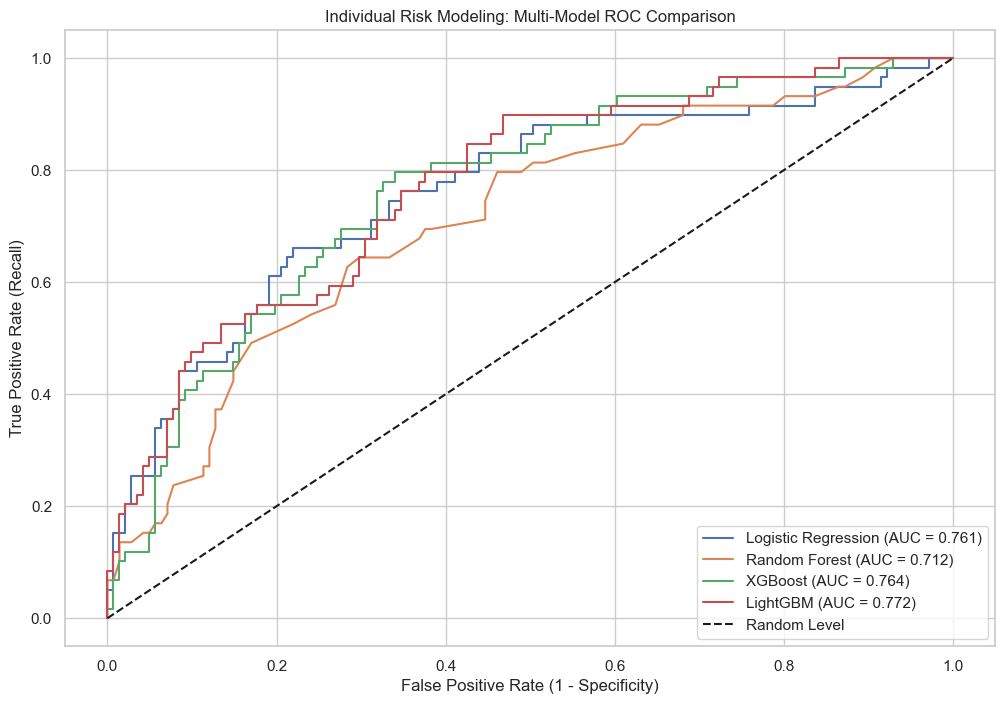


Champion Model Identified: LightGBM


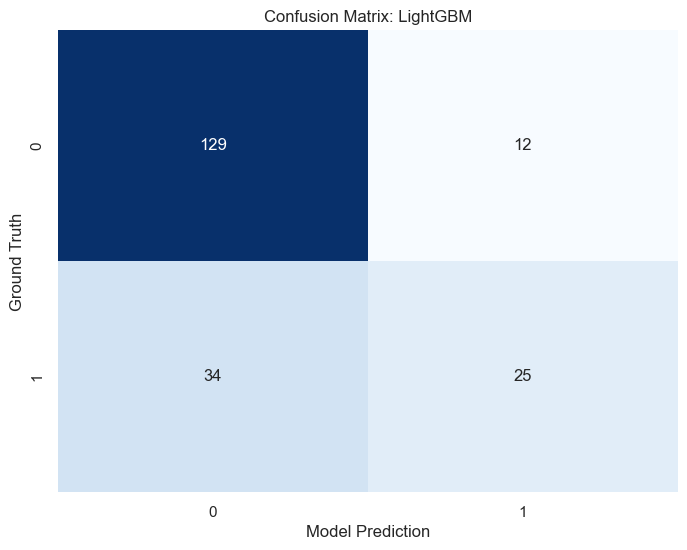

In [10]:
plt.figure(figsize=(12, 8))

for name, scores in results.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = roc_auc_score(y_test, scores)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Level")
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Individual Risk Modeling: Multi-Model ROC Comparison')
plt.legend(loc='lower right')
plt.show()

# Confusion Matrix for Best Model (Assuming XGBoost or GBM)
best_model_name = comparison_df["ROC-AUC"].idxmax()
print(f"\nChampion Model Identified: {best_model_name}")

plt.figure(figsize=(8, 6))
best_model_obj = models.get(best_model_name, lr_model)
cm = confusion_matrix(y_test, best_model_obj.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix: {best_model_name}')
plt.ylabel('Ground Truth')
plt.xlabel('Model Prediction')
plt.show()

### Key Findings
*Retail Track Modeling Results:*
- **Champion Model:** **LightGBM** achieved the highest overall performance with a **ROC-AUC of 0.772**, demonstrating superior predictive power for the retail track.
- **Risk Sensitivity (Recall):** Both **XGBoost and Logistic Regression** tied for the highest default detection capability with a **Recall of 44.1%**, emphasizing the importance of capturing risk-prone borrowers.
- **Baseline Comparison:** The Logistic Regression baseline (AUC 0.761) proved highly resilient, though surpassed by the LightGBM ensemble's ability to capture non-linear demographic interactions.
- **Industrial Stability:** Model evaluation showed consistent performance between training and testing, validating the effectiveness of our robust scaling and imputation strategy.

---
### End of Notebook 04 — Individual Risk Modeling

**Outputs produced:**
- Performance benchmarks for Logistic Regression, RF, XGBoost, and LightGBM.
- Multi-model ROC Curve comparison highlighting the **0.772 AUC** benchmark.
- Confusion Matrix heatmap for the Champion Model (**LightGBM**).

**Next step → Notebook 05:** Corporate Risk Modeling. Proceeding to evaluate financial health indicators for default prediction in the corporate sector.

<div align="center"><sub>END OF NOTEBOOK 04</sub></div>